In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [3]:
#Read the dataset
df = pd.read_csv(r"../data/DT_Placement.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (14, 6)


,ID,CGPA,Internships,Backlogs,Aptitude,Placed
0,S1,8.6,2,No,73,Yes
1,S2,9.4,2,No,76,Yes
2,S3,9.0,2,No,81,Yes
3,S4,5.2,0,Yes,48,No
4,S5,5.3,0,Yes,44,No


## Select X and y from dataset

In [5]:
X = df[["CGPA"]]
y = df["Aptitude"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (14, 1)
y shape: (14,)


## Use placed students only

There are 32,924 placed students with complete salary data

In [8]:
placed_df = df[df["Placed"] == "Yes"].copy()

print("Placed students:", len(placed_df))

Placed students: 8


In [9]:
X = placed_df[["CGPA"]]
y = placed_df["Aptitude"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8, 1)
y shape: (8,)


## Split the dataset into training and testing sets

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 6
Testing samples : 2


In [11]:
model = LinearRegression()

#Traing the model with training data
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.76]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['CGPA']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,55.69
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [12]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 55.69473944183749
Coefficient: 2.7587058532971107


In [13]:
#Predicting the salary package for training data

y_train_pred = model.predict(X_train)

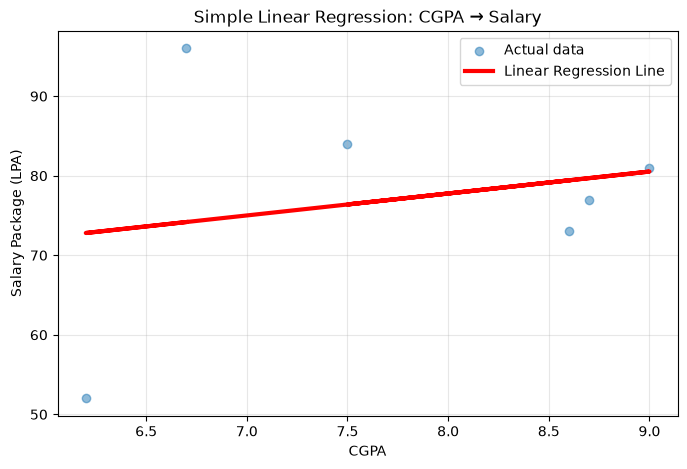

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_train["CGPA"],
    y_train,
    alpha=0.5,
    label="Actual data"
)

plt.plot(
    X_train["CGPA"],
    y_train_pred,
    color="red",
    linewidth=3,
    label="Linear Regression Line"
)

plt.xlabel("CGPA")
plt.ylabel("Salary Package (LPA)")
plt.title("Simple Linear Regression: CGPA → Salary")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Here red line goes upward from left to right.

That means:

1. As CGPA increases, the model predicts a higher salary package on average.

2. So there is a positive relationship between CGPA and predicted salary

The blue dots are the actual salary packages of students. The red line is the salary predicted using only CGPA. 

The upward slope indicates that students with higher CGPA tend to have higher predicted salaries. However, the large spread of blue points around the line shows that CGPA alone cannot completely explain salary variation.

  This is why we later move from Simple Linear Regression to Multiple Linear Regression by adding other relevant features

In [15]:
#predicting the salary package for testing data
y_test_pred = model.predict(X_test)

In [16]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 36.21349547934079
RMSE: 6.017764990371491
MAE : 6.005803902198075
R²  : -3.0237217199267548


In [17]:
## Give a new student's CGPA
new_cgpa = float(input("Enter CGPA: "))

## Predict salary

predicted_salary = model.predict([[new_cgpa]])[0]

print(f"Predicted Salary Package: {predicted_salary:.2f} LPA")

ValueError: could not convert string to float: ''